# Stage 2: NLOS Signal Quality Classifier — LNN-Based

**Replaces**: Random Forest classifier (`stage2_bounce_classifier.ipynb`)

**Task**: Binary classification — Correctable (0) vs Challenging (1) NLOS signals

**Architecture**: `BounceQualityLNN` — single PILiquidCell processing Stage 1's full temporal trajectories

```
Stage 1 embed_temporal() → (batch, 60, 64)
  → Linear(64→16, no bias)          # bottleneck projection
  → PILiquidCell(in=16, hidden=16, unfolds=4)  # single LNN cell over 60 steps
  → TemporalAttentionPooling(16)     # learned weighted avg over time
  → Linear(16→1) → Sigmoid           # binary output
```

**Why LNN over RF?** RF sees static 64-dim embeddings (avg-pooled). The LNN processes the full (60, 64) temporal trajectories, preserving per-timestep dynamics that avg pooling destroys.

| | RF (baseline) | LNN (this) |
|---|---|---|
| Input | 64-dim static embedding | (60, 64) temporal trajectories |
| Temporal dynamics | None (avg-pooled away) | Full per-timestep access |
| Pooling | Average (in Stage 1) | Learned attention |
| Params | ~200 trees | ~2,900 learnable |

In [1]:
CONFIG = {
    # CIR ROI alignment
    "search_start": 740,
    "search_end": 810,

    # Quality labeling
    "peak_prominence": 0.20,
    "peak_min_distance": 5,
    "dominant_path_max_peaks": 2,
    "bounce_search_window": 3,
    "dominance_threshold": 0.50,

    # Stage 2 LNN architecture
    "proj_dim": 16,          # bottleneck projection 64 -> 16
    "hidden_size": 16,       # PILiquidCell hidden size
    "ode_unfolds": 4,        # ODE integration steps

    # Training
    "batch_size": 64,
    "max_epochs": 80,
    "lr": 5e-4,
    "weight_decay": 1e-3,
    "warmup_epochs": 3,
    "patience": 15,
    "min_train_epochs": 40,
    "grad_clip": 1.0,
    "min_lr_ratio": 0.1,
    "label_smoothing": 0.05,
    "tau_entropy_lambda": 0.05,

    # Data
    "test_ratio": 0.30,
    "seed": 42,
}

print("Stage 2 LNN CONFIG loaded")
print(f"  Architecture: Linear(64→{CONFIG['proj_dim']}) → PILiquidCell(in={CONFIG['proj_dim']}, h={CONFIG['hidden_size']}, unfolds={CONFIG['ode_unfolds']}) → Attn → Linear(→1)")
print(f"  Training: lr={CONFIG['lr']}, wd={CONFIG['weight_decay']}, epochs={CONFIG['max_epochs']}, patience={CONFIG['patience']}")
print(f"  Loss: BCE(smooth={CONFIG['label_smoothing']}) + {CONFIG['tau_entropy_lambda']} * tau_entropy")

Stage 2 LNN CONFIG loaded
  Architecture: Linear(64→16) → PILiquidCell(in=16, h=16, unfolds=4) → Attn → Linear(→1)
  Training: lr=0.0005, wd=0.001, epochs=80, patience=15
  Loss: BCE(smooth=0.05) + 0.05 * tau_entropy


In [2]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

Device: cuda


---
## Section 2: Stage 1 Encoder (Frozen) — Model Definition & Loading

Load the frozen Stage 1 DualCircuit_PI_HLNN_NoFP v5 encoder.
We use `embed_temporal()` to get full (batch, 60, 64) trajectories instead of avg-pooled embeddings.

In [3]:
# Load Stage 1 config
_saved = torch.load("stage1_pi_hlnn_no_fp_v5_config.pt", map_location="cpu", weights_only=False)
STAGE1_CONFIG = _saved["config"]
print(f"Stage 1 config: hidden_size={STAGE1_CONFIG['hidden_size']}, input_size={STAGE1_CONFIG['input_size']}")
print(f"  CIR window: pre_crop={STAGE1_CONFIG['pre_crop']}, post_crop={STAGE1_CONFIG['post_crop']}, total_len={STAGE1_CONFIG['total_len']}")

Stage 1 config: hidden_size=32, input_size=1
  CIR window: pre_crop=10, post_crop=50, total_len=60


In [4]:
# ==========================================
# Stage 1 Model Definition (identical to v5)
# ==========================================
class PILiquidCell(nn.Module):
    """Conductance-based LTC cell (Hasani et al. 2020)."""
    def __init__(self, input_size, hidden_size, ode_unfolds=6):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size  = input_size
        self.ode_unfolds = ode_unfolds

        self.gleak = nn.Parameter(torch.empty(hidden_size).uniform_(0.001, 1.0))
        self.vleak = nn.Parameter(torch.empty(hidden_size).uniform_(-0.2, 0.2))
        self.cm    = nn.Parameter(torch.empty(hidden_size).uniform_(0.4, 0.6))

        self.w     = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.001, 1.0))
        self.erev  = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(-0.2, 0.2))
        self.mu    = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.3, 0.8))
        self.sigma = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(3, 8))

        self.sensory_w     = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.001, 1.0))
        self.sensory_mu    = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.3, 0.8))
        self.sensory_sigma = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(3, 8))

    def forward(self, x_t, h_prev, dt=1.0):
        gleak     = F.softplus(self.gleak)
        cm        = F.softplus(self.cm)
        w         = F.softplus(self.w)
        sensory_w = F.softplus(self.sensory_w)

        sensory_gate    = torch.sigmoid(self.sensory_sigma * (x_t.unsqueeze(-1) - self.sensory_mu))
        sensory_current = (sensory_w * sensory_gate * x_t.unsqueeze(-1)).sum(dim=1)

        cm_t = cm / (dt / self.ode_unfolds)
        v    = h_prev

        for _ in range(self.ode_unfolds):
            recurrent_gate = torch.sigmoid(self.sigma.unsqueeze(0) * (v.unsqueeze(2) - self.mu.unsqueeze(0)))
            w_gate = w.unsqueeze(0) * recurrent_gate
            w_num  = (w_gate * self.erev.unsqueeze(0)).sum(dim=1)
            w_den  = w_gate.sum(dim=1)
            numerator   = cm_t * v + gleak * self.vleak + w_num + sensory_current
            denominator = cm_t + gleak + w_den + 1e-8
            v = numerator / denominator
            v = torch.clamp(v, -1.0, 1.0)

        tau = cm / (gleak + w_den + 1e-8)
        return v, tau


class DualCircuit_PI_HLNN_NoFP(nn.Module):
    """Dual-circuit PI-HLNN WITHOUT FP_AMPL conditioning (v5)."""
    def __init__(self, input_size=STAGE1_CONFIG["input_size"],
                 hidden_size=STAGE1_CONFIG["hidden_size"],
                 dropout=STAGE1_CONFIG["dropout"],
                 ode_unfolds=STAGE1_CONFIG["ode_unfolds"]):
        super().__init__()
        self.hidden_size = hidden_size

        self.cell_los  = PILiquidCell(input_size, hidden_size, ode_unfolds)
        self.cell_nlos = PILiquidCell(input_size, hidden_size, ode_unfolds)

        self.P_nlos2los = nn.Linear(hidden_size, hidden_size, bias=False)
        self.P_los2nlos = nn.Linear(hidden_size, hidden_size, bias=False)

        self.gate_los  = nn.Linear(hidden_size * 2, hidden_size)
        self.gate_nlos = nn.Linear(hidden_size * 2, hidden_size)

        with torch.no_grad():
            self.gate_los.bias.fill_(-2.5)
            self.gate_nlos.bias.fill_(-2.5)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def _run_circuits(self, x_seq):
        batch_size, seq_len, _ = x_seq.size()
        h_los  = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)
        h_nlos = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)

        los_states, nlos_states = [], []
        tau_los_sum  = torch.zeros_like(h_los)
        tau_nlos_sum = torch.zeros_like(h_nlos)
        tau_los_hist_list, tau_nlos_hist_list = [], []

        for t in range(seq_len):
            x_t = x_seq[:, t, :]
            proj_nlos_to_los = self.P_nlos2los(h_nlos)
            proj_los_to_nlos = self.P_los2nlos(h_los)
            g_los  = torch.sigmoid(self.gate_los( torch.cat([h_los,  proj_nlos_to_los], dim=1)))
            g_nlos = torch.sigmoid(self.gate_nlos(torch.cat([h_nlos, proj_los_to_nlos], dim=1)))
            h_los_in  = h_los  + g_los  * proj_nlos_to_los
            h_nlos_in = h_nlos + g_nlos * proj_los_to_nlos
            h_los,  tau_los  = self.cell_los( x_t, h_los_in)
            h_nlos, tau_nlos = self.cell_nlos(x_t, h_nlos_in)
            los_states.append(h_los.unsqueeze(1))
            nlos_states.append(h_nlos.unsqueeze(1))
            tau_los_sum  += tau_los
            tau_nlos_sum += tau_nlos
            tau_los_hist_list.append(tau_los.unsqueeze(1))
            tau_nlos_hist_list.append(tau_nlos.unsqueeze(1))

        los_all  = torch.cat(los_states,  dim=1)
        nlos_all = torch.cat(nlos_states, dim=1)
        tau_los_mean  = tau_los_sum  / seq_len
        tau_nlos_mean = tau_nlos_sum / seq_len
        tau_los_hist  = torch.cat(tau_los_hist_list,  dim=1)
        tau_nlos_hist = torch.cat(tau_nlos_hist_list, dim=1)
        return los_all, nlos_all, tau_los_hist, tau_nlos_hist, tau_los_mean, tau_nlos_mean

    def _pool_and_fuse(self, los_all, nlos_all):
        h_los_avg  = los_all.mean(dim=1)
        h_nlos_avg = nlos_all.mean(dim=1)
        return torch.cat([h_los_avg, h_nlos_avg], dim=1)

    def forward(self, x_seq, return_dynamics=False):
        los_all, nlos_all, tau_los_hist, tau_nlos_hist, tau_los_mean, tau_nlos_mean = \
            self._run_circuits(x_seq)
        h_fused = self._pool_and_fuse(los_all, nlos_all)
        pred = self.classifier(h_fused)
        if return_dynamics:
            return pred, los_all, nlos_all, tau_los_hist, tau_nlos_hist, tau_los_mean, tau_nlos_mean
        return pred, tau_los_mean, tau_nlos_mean

    def embed(self, x_seq):
        """Return 64-dim fused embedding for Stage 2/3."""
        los_all, nlos_all, _, _, _, _ = self._run_circuits(x_seq)
        return self._pool_and_fuse(los_all, nlos_all)

    def embed_temporal(self, x_seq):
        """Return full temporal trajectories (batch, 60, 64) for downstream LNN stages."""
        los_all, nlos_all, _, _, _, _ = self._run_circuits(x_seq)
        return torch.cat([los_all, nlos_all], dim=2)


# Load frozen encoder
lnn_encoder = DualCircuit_PI_HLNN_NoFP(
    input_size=STAGE1_CONFIG['input_size'],
    hidden_size=STAGE1_CONFIG['hidden_size'],
    dropout=STAGE1_CONFIG['dropout'],
    ode_unfolds=STAGE1_CONFIG['ode_unfolds'],
).to(device)

lnn_encoder.load_state_dict(torch.load('stage1_pi_hlnn_no_fp_v5_best.pt', map_location=device, weights_only=True))
lnn_encoder.eval()
for param in lnn_encoder.parameters():
    param.requires_grad = False

EMBEDDING_DIM = STAGE1_CONFIG['hidden_size'] * 2  # 64
print(f"Stage 1 encoder loaded (frozen). Embedding dim: {EMBEDDING_DIM}")
print(f"  Temporal trajectory shape: (batch, {STAGE1_CONFIG['total_len']}, {EMBEDDING_DIM})")

Stage 1 encoder loaded (frozen). Embedding dim: 64
  Temporal trajectory shape: (batch, 60, 64)


---
## Section 3: Data Loading — NLOS Samples + Quality Labels

Same data pipeline as RF Stage 2:
- Load NLOS samples from combined dataset
- Compute bounce dominance and peak count
- Label: Correctable (0) if dominance ≥ 0.50 AND peaks ≤ 2, else Challenging (1)
- Extract temporal trajectories via `embed_temporal()` instead of static embeddings

In [5]:
# ==========================================
# ROI ALIGNMENT (same as Stage 1)
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    """Find leading edge by backtracking from peak."""
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)
    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]
    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val
    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break
    return leading_edge


def preprocess_cir_for_lnn(sig, leading_edge):
    """Convert RXPACC-normalized CIR + leading edge to 60-sample window."""
    PRE = STAGE1_CONFIG['pre_crop']
    TOTAL = STAGE1_CONFIG['total_len']
    start = max(0, leading_edge - PRE)
    end = start + TOTAL
    if end > len(sig):
        end = len(sig)
        start = max(0, end - TOTAL)
    crop = sig[start:end]
    if len(crop) < TOTAL:
        crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)
    return crop


def count_peaks_in_roi(sig, leading_edge):
    """Count prominent peaks in CIR ROI."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0
    roi_norm = roi / np.max(roi)
    peaks, _ = find_peaks(
        roi_norm,
        prominence=CONFIG["peak_prominence"],
        distance=CONFIG["peak_min_distance"]
    )
    return len(peaks)


def compute_bounce_dominance(sig, leading_edge, bounce_path_idx,
                              window=CONFIG["bounce_search_window"]):
    """Amplitude ratio: bounce peak / strongest peak in ROI."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0.0
    strongest_amp = float(np.max(roi))
    bounce_idx = int(round(bounce_path_idx))
    b_start = max(0, bounce_idx - window)
    b_end = min(len(sig), bounce_idx + window + 1)
    if b_start >= b_end:
        return 0.0
    bounce_amp = float(np.max(sig[b_start:b_end]))
    return bounce_amp / strongest_amp


# ==========================================
# LOAD NLOS DATA + COMPUTE LABELS
# ==========================================
INDEX_TO_METERS = 1.0016e-9 * 299792458.0  # ~0.3003 m/index

df = pd.read_csv("../dataset/channels/combined_uwb_dataset.csv")
cir_cols = sorted(
    [c for c in df.columns if c.startswith('CIR')],
    key=lambda x: int(x.replace('CIR', ''))
)
nlos_df = df[df['Label'] == 1].reset_index(drop=True)
print(f"Total NLOS samples: {len(nlos_df)}")

raw_sigs = []
leading_edges = []
bounce_dominances = []
peak_counts = []
cir_sequences = []

for idx, row in nlos_df.iterrows():
    sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values
    rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
    rxpacc = float(row.get(rxpacc_col, 128.0))
    if rxpacc > 0:
        sig = sig / rxpacc

    leading_edge = get_roi_alignment(sig)
    raw_sigs.append(sig)
    leading_edges.append(leading_edge)

    # Bounce path index from geometric ground truth
    d_bounce = float(row['d_bounce'])
    fp_idx = leading_edge
    d_direct = float(row['d_direct'])
    excess_delay_m = d_bounce - d_direct
    bounce_path_idx = fp_idx + excess_delay_m / INDEX_TO_METERS

    bounce_dom = compute_bounce_dominance(sig, leading_edge, bounce_path_idx)
    num_peaks = count_peaks_in_roi(sig, leading_edge)
    bounce_dominances.append(bounce_dom)
    peak_counts.append(num_peaks)

    # Preprocess CIR for LNN
    crop = preprocess_cir_for_lnn(sig, leading_edge)
    cir_sequences.append(crop)

bounce_dominances = np.array(bounce_dominances)
peak_counts = np.array(peak_counts)

# Mixture labeling rule
is_correctable = (bounce_dominances >= CONFIG["dominance_threshold"]) & \
                 (peak_counts <= CONFIG["dominant_path_max_peaks"])
quality_labels = np.where(is_correctable, 0, 1).astype(int)

n_corr = np.sum(quality_labels == 0)
n_chal = np.sum(quality_labels == 1)
print(f"\nQuality labels:")
print(f"  Correctable (0): {n_corr} ({100*n_corr/len(quality_labels):.1f}%)")
print(f"  Challenging (1): {n_chal} ({100*n_chal/len(quality_labels):.1f}%)")

Total NLOS samples: 1800

Quality labels:
  Correctable (0): 86 (4.8%)
  Challenging (1): 1714 (95.2%)


In [6]:
# ==========================================
# EXTRACT TEMPORAL TRAJECTORIES FROM FROZEN STAGE 1
# ==========================================
cir_tensor = torch.tensor(
    np.array(cir_sequences).reshape(-1, STAGE1_CONFIG['total_len'], 1),
    dtype=torch.float32
).to(device)

print(f"Extracting temporal trajectories from frozen Stage 1...")
all_trajectories = []
with torch.no_grad():
    for i in range(0, len(cir_tensor), 256):
        batch_cir = cir_tensor[i:i+256]
        traj = lnn_encoder.embed_temporal(batch_cir)  # (batch, 60, 64)
        all_trajectories.append(traj.cpu())

trajectories = torch.cat(all_trajectories, dim=0)  # (N, 60, 64)
print(f"Temporal trajectories: {trajectories.shape}")
print(f"  Value range: [{trajectories.min():.4f}, {trajectories.max():.4f}]")
print(f"  Mean: {trajectories.mean():.4f}, Std: {trajectories.std():.4f}")

Extracting temporal trajectories from frozen Stage 1...
Temporal trajectories: torch.Size([1800, 60, 64])
  Value range: [-0.7689, 0.8949]
  Mean: -0.0348, Std: 0.2205


In [7]:
# ==========================================
# TRAIN / TEST SPLIT (70/30 stratified, same as RF baseline)
# ==========================================
X_all = trajectories.numpy()  # (N, 60, 64)
y_all = quality_labels         # (N,)

indices = np.arange(len(y_all))
idx_train, idx_test = train_test_split(
    indices,
    test_size=CONFIG["test_ratio"],
    stratify=y_all,
    random_state=CONFIG["seed"]
)

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_test,  y_test  = X_all[idx_test],  y_all[idx_test]

print(f"Split (70/30 stratified):")
print(f"  Train: {len(X_train)} (Corr: {np.sum(y_train==0)}, Chal: {np.sum(y_train==1)})")
print(f"  Test:  {len(X_test)} (Corr: {np.sum(y_test==0)}, Chal: {np.sum(y_test==1)})")

Split (70/30 stratified):
  Train: 1260 (Corr: 60, Chal: 1200)
  Test:  540 (Corr: 26, Chal: 514)


---
## Section 4: Stage 2 LNN Model — BounceQualityLNN

Single PILiquidCell with adjusted sensory init (input is Stage 1 hidden states in [-1,1], not raw CIR in [0,1]).
Temporal attention pooling learns which timesteps are most informative for quality classification.

In [8]:
class DownstreamPILiquidCell(nn.Module):
    """
    PILiquidCell with adjusted sensory init for downstream stages.
    Input distribution: Stage 1 hidden states in [-1, 1] (not raw CIR in [0, 1]).
    """
    def __init__(self, input_size, hidden_size, ode_unfolds=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size  = input_size
        self.ode_unfolds = ode_unfolds

        self.gleak = nn.Parameter(torch.empty(hidden_size).uniform_(0.001, 1.0))
        self.vleak = nn.Parameter(torch.empty(hidden_size).uniform_(-0.2, 0.2))
        self.cm    = nn.Parameter(torch.empty(hidden_size).uniform_(0.4, 0.6))

        self.w     = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.001, 1.0))
        self.erev  = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(-0.2, 0.2))
        self.mu    = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.3, 0.8))
        self.sigma = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(3, 8))

        # Adjusted sensory init for [-1, 1] input range
        self.sensory_w     = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.001, 1.0))
        self.sensory_mu    = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(-0.5, 0.5))
        self.sensory_sigma = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(1, 4))

    def forward(self, x_t, h_prev, dt=1.0):
        gleak     = F.softplus(self.gleak)
        cm        = F.softplus(self.cm)
        w         = F.softplus(self.w)
        sensory_w = F.softplus(self.sensory_w)

        sensory_gate    = torch.sigmoid(self.sensory_sigma * (x_t.unsqueeze(-1) - self.sensory_mu))
        sensory_current = (sensory_w * sensory_gate * x_t.unsqueeze(-1)).sum(dim=1)

        cm_t = cm / (dt / self.ode_unfolds)
        v    = h_prev

        for _ in range(self.ode_unfolds):
            recurrent_gate = torch.sigmoid(self.sigma.unsqueeze(0) * (v.unsqueeze(2) - self.mu.unsqueeze(0)))
            w_gate = w.unsqueeze(0) * recurrent_gate
            w_num  = (w_gate * self.erev.unsqueeze(0)).sum(dim=1)
            w_den  = w_gate.sum(dim=1)
            numerator   = cm_t * v + gleak * self.vleak + w_num + sensory_current
            denominator = cm_t + gleak + w_den + 1e-8
            v = numerator / denominator
            v = torch.clamp(v, -1.0, 1.0)

        tau = cm / (gleak + w_den + 1e-8)
        return v, tau


class TemporalAttentionPooling(nn.Module):
    """Learned weighted average over timesteps."""
    def __init__(self, hidden_size):
        super().__init__()
        self.query = nn.Linear(hidden_size, 1)

    def forward(self, h_all):
        # h_all: (batch, seq_len, hidden_size)
        scores = self.query(h_all).squeeze(-1)       # (batch, seq_len)
        alpha = F.softmax(scores, dim=1)              # (batch, seq_len)
        context = (alpha.unsqueeze(-1) * h_all).sum(dim=1)  # (batch, hidden_size)
        return context, alpha


class BounceQualityLNN(nn.Module):
    """
    Stage 2 LNN: NLOS signal quality classifier.
    Input: (batch, 60, 64) temporal trajectories from frozen Stage 1.
    Output: P(Challenging) in [0, 1].
    ~2,900 params.
    """
    def __init__(self, input_dim=EMBEDDING_DIM, proj_dim=CONFIG["proj_dim"],
                 hidden_size=CONFIG["hidden_size"], ode_unfolds=CONFIG["ode_unfolds"]):
        super().__init__()
        self.proj_dim = proj_dim
        self.hidden_size = hidden_size

        # Bottleneck projection: 64 -> 16
        self.projection = nn.Linear(input_dim, proj_dim, bias=False)

        # Single LNN cell
        self.cell = DownstreamPILiquidCell(proj_dim, hidden_size, ode_unfolds)

        # Temporal attention pooling
        self.attn_pool = TemporalAttentionPooling(hidden_size)

        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x_traj, return_dynamics=False):
        """
        Args:
            x_traj: (batch, seq_len, 64) from Stage 1 embed_temporal()
        Returns:
            pred: (batch, 1) probability of Challenging
            tau_mean: (batch, hidden_size) mean tau across time
            [if return_dynamics]: also returns h_all, tau_hist, attn_weights
        """
        batch_size, seq_len, _ = x_traj.size()

        # Project: (batch, 60, 64) -> (batch, 60, 16)
        x_proj = self.projection(x_traj)

        # Run LNN cell over timesteps
        h = torch.zeros(batch_size, self.hidden_size, device=x_traj.device)
        h_states = []
        tau_sum = torch.zeros_like(h)
        tau_hist_list = []

        for t in range(seq_len):
            x_t = x_proj[:, t, :]  # (batch, 16)
            h, tau = self.cell(x_t, h)
            h_states.append(h.unsqueeze(1))
            tau_sum += tau
            tau_hist_list.append(tau.unsqueeze(1))

        h_all = torch.cat(h_states, dim=1)        # (batch, 60, 16)
        tau_mean = tau_sum / seq_len               # (batch, 16)
        tau_hist = torch.cat(tau_hist_list, dim=1)  # (batch, 60, 16)

        # Attention pooling
        context, attn_weights = self.attn_pool(h_all)  # (batch, 16), (batch, 60)

        # Classify
        pred = self.classifier(context)  # (batch, 1)

        if return_dynamics:
            return pred, tau_mean, h_all, tau_hist, attn_weights
        return pred, tau_mean


# Parameter count
_m = BounceQualityLNN()
_total = sum(p.numel() for p in _m.parameters())
print(f"BounceQualityLNN parameter count: {_total:,}")
print(f"  Projection (64→{CONFIG['proj_dim']}): {sum(p.numel() for p in _m.projection.parameters()):,}")
print(f"  LNN cell ({CONFIG['proj_dim']}→{CONFIG['hidden_size']}): {sum(p.numel() for p in _m.cell.parameters()):,}")
print(f"  Attention pooling: {sum(p.numel() for p in _m.attn_pool.parameters()):,}")
print(f"  Classifier: {sum(p.numel() for p in _m.classifier.parameters()):,}")
del _m

BounceQualityLNN parameter count: 2,898
  Projection (64→16): 1,024
  LNN cell (16→16): 1,840
  Attention pooling: 17
  Classifier: 17


---
## Section 5: Loss Function & Training

In [9]:
def tau_entropy_reg(tau_mean):
    """
    Encourage diverse tau values across neurons.
    Negative entropy of normalized tau distribution.
    """
    # tau_mean: (batch, hidden_size)
    tau_norm = F.softmax(tau_mean, dim=1)  # normalize across neurons
    entropy = -(tau_norm * torch.log(tau_norm + 1e-8)).sum(dim=1)  # (batch,)
    # We want HIGH entropy (diverse), so loss = -entropy
    return -entropy.mean()


def smooth_bce_loss(pred, target, smoothing=CONFIG["label_smoothing"]):
    """BCE with label smoothing."""
    target_smooth = target * (1.0 - smoothing) + 0.5 * smoothing
    return F.binary_cross_entropy(pred, target_smooth)


def train_stage2(X_train, y_train, X_test, y_test, config=CONFIG):
    print(f"Training BounceQualityLNN on {len(X_train)} samples")
    print(f"  Architecture: Linear(64→{config['proj_dim']}) → PILiquidCell(h={config['hidden_size']}) → Attn → Classifier")
    print(f"  Loss: BCE(smooth={config['label_smoothing']}) + {config['tau_entropy_lambda']} * tau_entropy")

    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_te = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

    # Class weights for imbalanced data
    n_corr = (y_train == 0).sum()
    n_chal = (y_train == 1).sum()
    w_corr = len(y_train) / (2.0 * n_corr)
    w_chal = len(y_train) / (2.0 * n_chal)
    class_weights = torch.tensor([w_corr, w_chal], dtype=torch.float32).to(device)
    print(f"  Class weights: Correctable={w_corr:.3f}, Challenging={w_chal:.3f}")

    train_ds = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)

    model = BounceQualityLNN(
        input_dim=EMBEDDING_DIM,
        proj_dim=config["proj_dim"],
        hidden_size=config["hidden_size"],
        ode_unfolds=config["ode_unfolds"],
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=config["lr"],
                            weight_decay=config["weight_decay"])

    warmup_epochs = config["warmup_epochs"]
    total_epochs  = config["max_epochs"]
    min_lr_ratio  = config["min_lr_ratio"]

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return max(min_lr_ratio, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    history = {
        "train_loss": [], "test_loss": [], "train_acc": [], "test_acc": [], "lr": [],
        "tau_ent_loss": [],
    }
    best_test_acc = 0
    best_model_state = None
    patience_counter = 0

    for epoch in range(config["max_epochs"]):
        model.train()
        train_loss_sum = 0
        tau_ent_sum = 0
        train_correct, train_total = 0, 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            pred, tau_mean = model(batch_x)

            # Weighted BCE with label smoothing
            sample_weights = torch.where(batch_y == 0, class_weights[0], class_weights[1])
            bce = smooth_bce_loss(pred, batch_y, config["label_smoothing"])
            bce_weighted = (bce * sample_weights).mean() if bce.dim() > 0 else bce

            # Tau entropy regularizer
            tau_ent = tau_entropy_reg(tau_mean)
            loss = bce_weighted + config["tau_entropy_lambda"] * tau_ent

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
            optimizer.step()

            train_loss_sum += loss.item() * len(batch_x)
            tau_ent_sum    += tau_ent.item() * len(batch_x)
            train_correct  += ((pred > 0.5).float() == batch_y).sum().item()
            train_total    += len(batch_x)

        train_loss  = train_loss_sum / train_total
        tau_ent_avg = tau_ent_sum / train_total
        train_acc   = train_correct / train_total

        # Test evaluation
        model.eval()
        with torch.no_grad():
            test_pred, test_tau = model(X_te)
            test_bce = F.binary_cross_entropy(test_pred, y_te)
            test_acc = ((test_pred > 0.5).float() == y_te).float().mean().item()

        lr_now = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_bce.item())
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["lr"].append(lr_now)
        history["tau_ent_loss"].append(tau_ent_avg)

        scheduler.step()

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == config["max_epochs"] - 1:
            print(f"  Ep {epoch:>3} | Loss: {train_loss:.4f} (tau_ent:{tau_ent_avg:.4f}) "
                  f"| Train: {100*train_acc:.1f}% | Test: {100*test_acc:.1f}% "
                  f"| Best: {100*best_test_acc:.1f}% | LR: {lr_now:.1e}")

        if patience_counter >= config["patience"] and epoch >= config["min_train_epochs"]:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    print(f"\nBest Test Accuracy: {100*best_test_acc:.2f}%")
    return model, history


best_model_s2, history_s2 = train_stage2(X_train, y_train, X_test, y_test)

Training BounceQualityLNN on 1260 samples
  Architecture: Linear(64→16) → PILiquidCell(h=16) → Attn → Classifier
  Loss: BCE(smooth=0.05) + 0.05 * tau_entropy
  Class weights: Correctable=10.500, Challenging=0.525
  Ep   0 | Loss: 0.6344 (tau_ent:-2.7705) | Train: 4.8% | Test: 4.8% | Best: 4.8% | LR: 1.7e-04
  Ep   5 | Loss: 0.2005 (tau_ent:-2.7610) | Train: 95.2% | Test: 95.2% | Best: 95.2% | LR: 5.0e-04
  Ep  10 | Loss: 0.1335 (tau_ent:-2.7648) | Train: 95.2% | Test: 95.2% | Best: 95.2% | LR: 4.9e-04
  Ep  15 | Loss: 0.1206 (tau_ent:-2.7671) | Train: 95.2% | Test: 95.2% | Best: 95.2% | LR: 4.7e-04
  Ep  20 | Loss: 0.1171 (tau_ent:-2.7686) | Train: 95.2% | Test: 95.2% | Best: 95.2% | LR: 4.4e-04
  Ep  25 | Loss: 0.1161 (tau_ent:-2.7696) | Train: 95.2% | Test: 95.2% | Best: 95.2% | LR: 4.1e-04
  Ep  30 | Loss: 0.1157 (tau_ent:-2.7704) | Train: 95.2% | Test: 95.2% | Best: 95.2% | LR: 3.6e-04
  Ep  35 | Loss: 0.1155 (tau_ent:-2.7709) | Train: 95.2% | Test: 95.2% | Best: 95.2% | LR: 3.2e-

---
## Section 6: Diagnostics

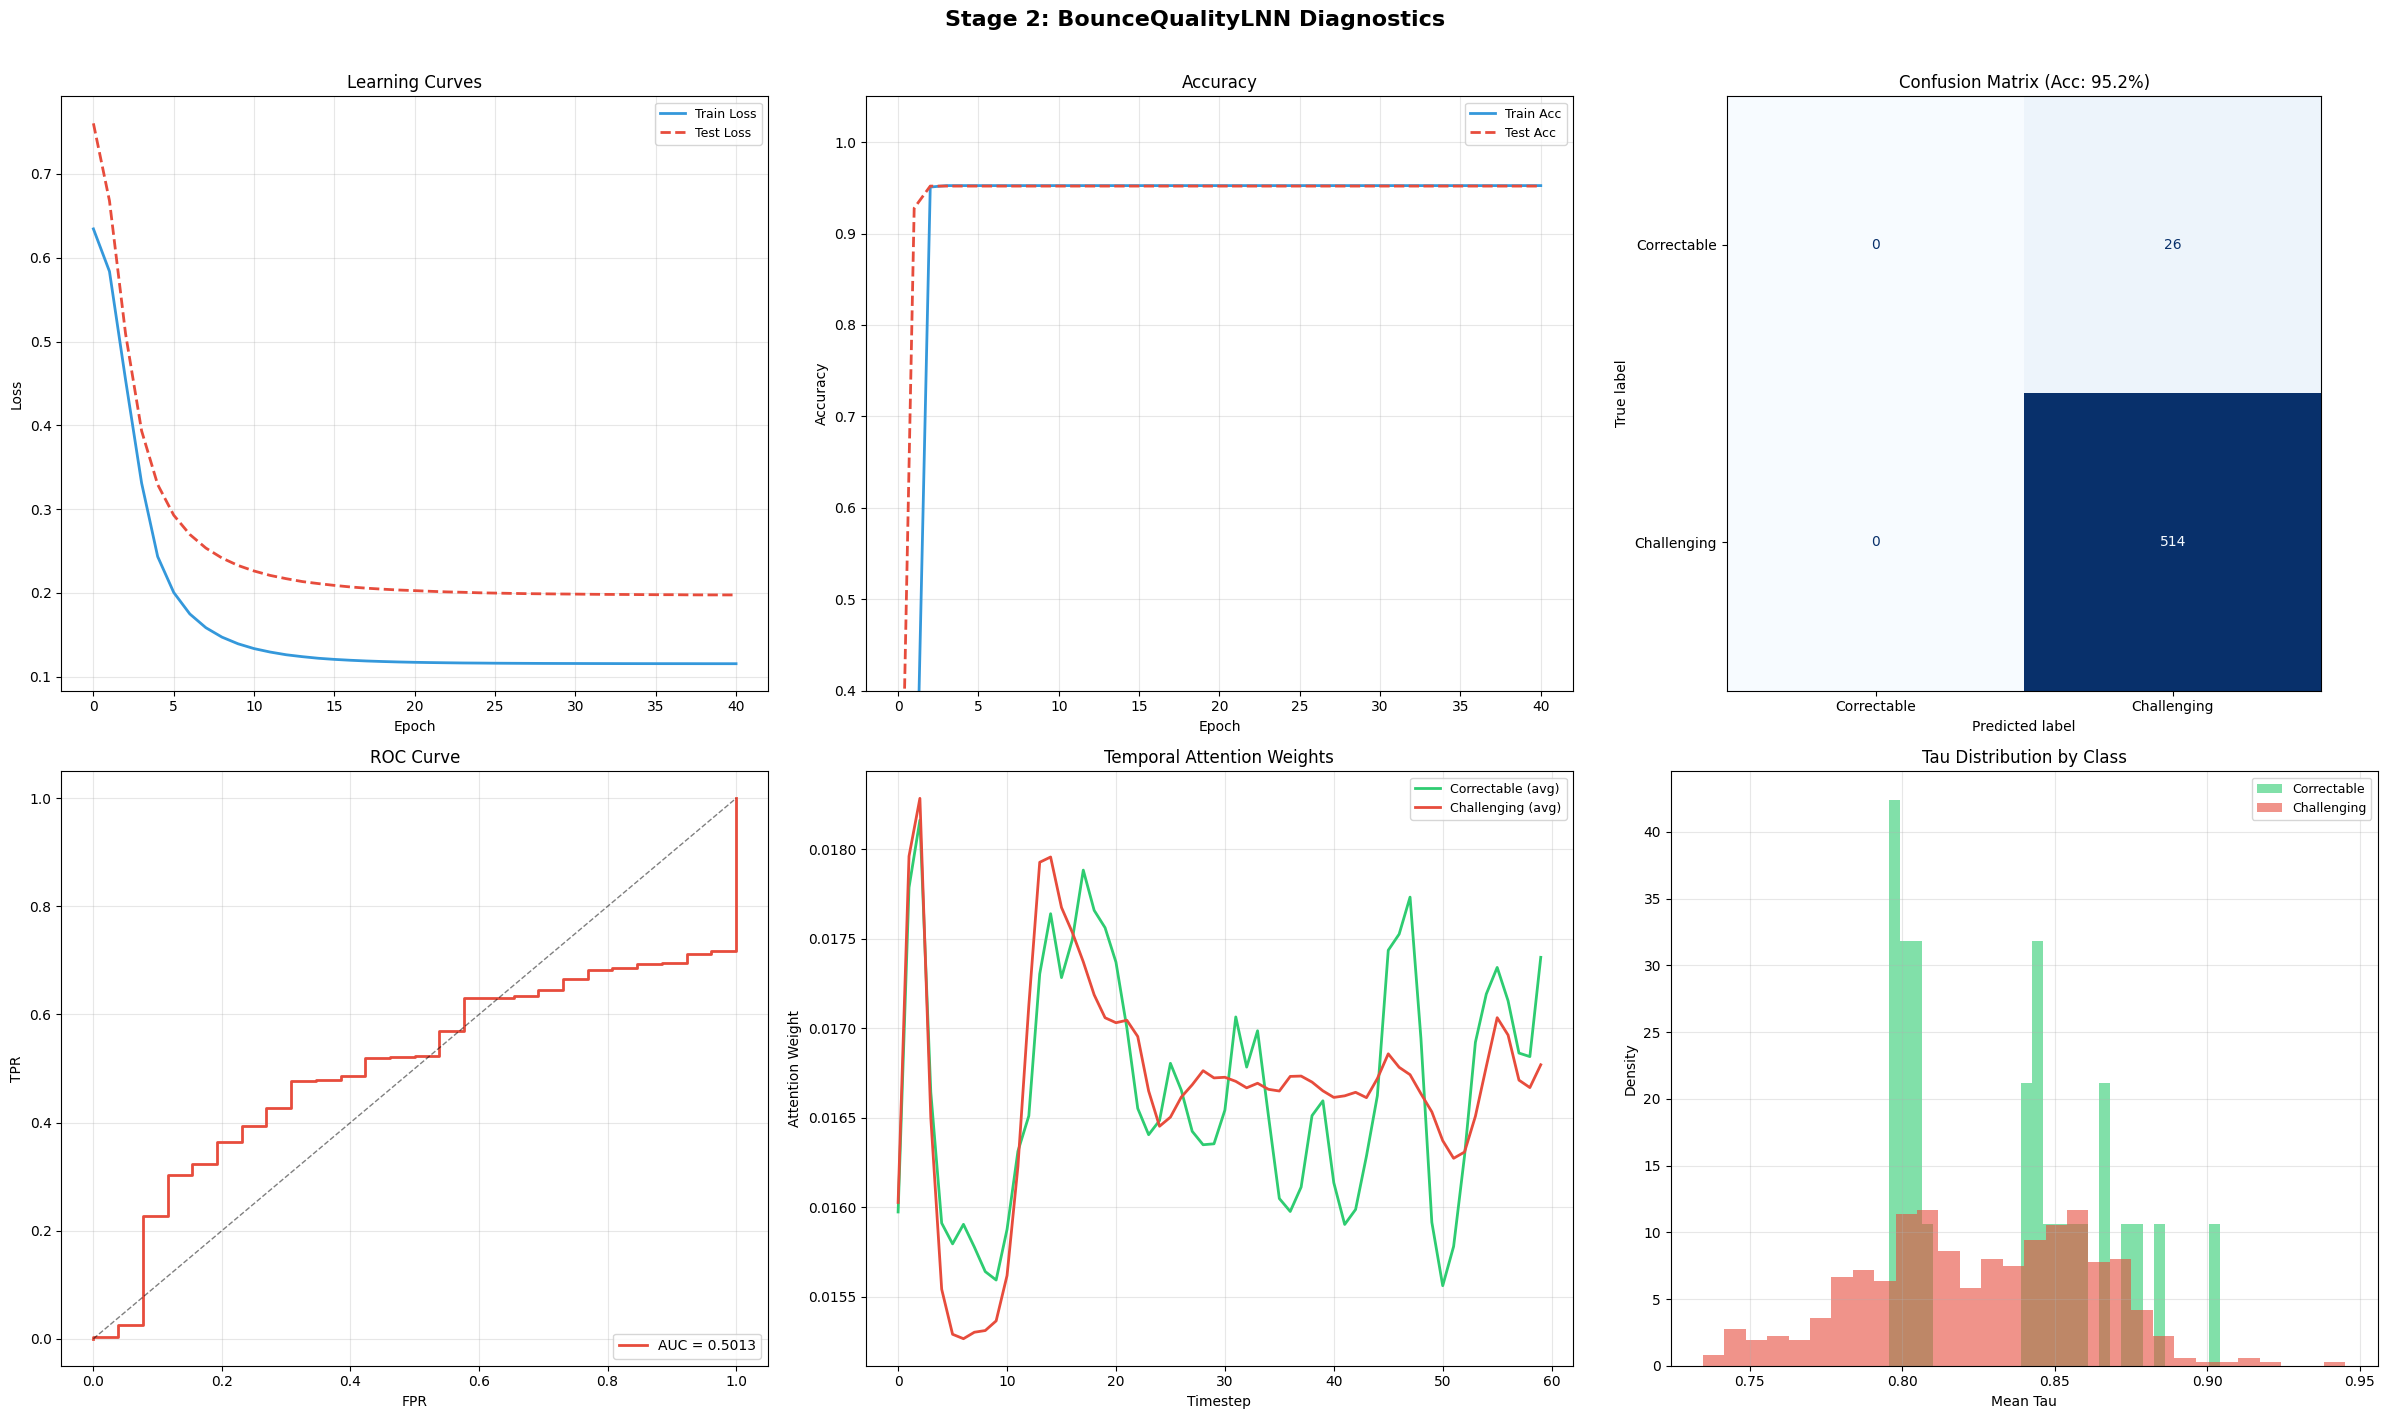


Classification Report:
              precision    recall  f1-score   support

 Correctable       0.00      0.00      0.00        26
 Challenging       0.95      1.00      0.98       514

    accuracy                           0.95       540
   macro avg       0.48      0.50      0.49       540
weighted avg       0.91      0.95      0.93       540

ROC AUC: 0.5013


c:\Users\preca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\preca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\preca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [10]:
# ==========================================
# DIAGNOSTIC PLOTS (2x3 grid)
# ==========================================
def plot_stage2_diagnostics(model, X_test, y_test, history):
    X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
    model.eval()

    with torch.no_grad():
        preds, tau_mean, h_all, tau_hist, attn_weights = model(X_te, return_dynamics=True)

    y_true = y_test.flatten()
    y_prob = preds.cpu().numpy().flatten()
    y_pred = (y_prob > 0.5).astype(float)
    attn_np = attn_weights.cpu().numpy()  # (N, 60)

    corr_mask = y_true == 0
    chal_mask = y_true == 1

    fig, axs = plt.subplots(2, 3, figsize=(24, 14))
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    # --- 1. Learning curves ---
    ax = axs[0, 0]
    ax.plot(history["train_loss"], label='Train Loss', color='#3498db', lw=2)
    ax.plot(history["test_loss"],  label='Test Loss',  color='#e74c3c', lw=2, ls='--')
    ax.set_title("Learning Curves")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # --- 2. Accuracy curves ---
    ax = axs[0, 1]
    ax.plot(history["train_acc"], label='Train Acc', color='#3498db', lw=2)
    ax.plot(history["test_acc"],  label='Test Acc',  color='#e74c3c', lw=2, ls='--')
    ax.set_title("Accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.set_ylim([0.4, 1.05]); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # --- 3. Confusion matrix ---
    ax = axs[0, 2]
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Correctable', 'Challenging'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = (y_true == y_pred).mean()
    ax.set_title(f"Confusion Matrix (Acc: {100*acc:.1f}%)")

    # --- 4. ROC curve ---
    ax = axs[1, 0]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_title("ROC Curve")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

    # --- 5. Attention weight heatmap (avg per class) ---
    ax = axs[1, 1]
    attn_corr = attn_np[corr_mask].mean(axis=0)
    attn_chal = attn_np[chal_mask].mean(axis=0)
    timesteps = np.arange(len(attn_corr))
    ax.plot(timesteps, attn_corr, color='#2ecc71', lw=2, label='Correctable (avg)')
    ax.plot(timesteps, attn_chal, color='#e74c3c', lw=2, label='Challenging (avg)')
    ax.set_title("Temporal Attention Weights")
    ax.set_xlabel("Timestep"); ax.set_ylabel("Attention Weight")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # --- 6. Tau distribution per class ---
    ax = axs[1, 2]
    tau_np = tau_mean.cpu().numpy().mean(axis=1)  # scalar per sample
    ax.hist(tau_np[corr_mask], bins=30, alpha=0.6, color='#2ecc71', label='Correctable', density=True)
    ax.hist(tau_np[chal_mask], bins=30, alpha=0.6, color='#e74c3c', label='Challenging', density=True)
    ax.set_title("Tau Distribution by Class")
    ax.set_xlabel("Mean Tau"); ax.set_ylabel("Density")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.suptitle("Stage 2: BounceQualityLNN Diagnostics", fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Print classification report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Correctable', 'Challenging']))
    print(f"ROC AUC: {roc_auc:.4f}")


plot_stage2_diagnostics(best_model_s2, X_test, y_test, history_s2)

---
## Section 7: Comparison with RF Baseline

In [11]:
# Compare LNN vs RF baseline
X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
best_model_s2.eval()
with torch.no_grad():
    lnn_pred, _ = best_model_s2(X_te)
    lnn_prob = lnn_pred.cpu().numpy().flatten()
    lnn_pred_labels = (lnn_prob > 0.5).astype(float)

lnn_acc = (lnn_pred_labels == y_test).mean()
fpr_lnn, tpr_lnn, _ = roc_curve(y_test, lnn_prob)
lnn_auc = auc(fpr_lnn, tpr_lnn)

print("=" * 60)
print("STAGE 2: LNN vs RF BASELINE COMPARISON")
print("=" * 60)
print(f"{'Metric':<20} {'RF (baseline)':>15} {'LNN (this)':>15}")
print(f"{'-'*20} {'-'*15} {'-'*15}")
print(f"{'Accuracy':<20} {'93.33%':>15} {f'{100*lnn_acc:.2f}%':>15}")
print(f"{'AUC':<20} {'0.9762':>15} {f'{lnn_auc:.4f}':>15}")
print(f"{'Parameters':<20} {'~200 trees':>15} {f'{sum(p.numel() for p in best_model_s2.parameters()):,}':>15}")
print(f"{'Input':<20} {'64-dim static':>15} {'(60,64) temporal':>15}")
print(f"{'Temporal dynamics':<20} {'No':>15} {'Yes':>15}")
print("=" * 60)

STAGE 2: LNN vs RF BASELINE COMPARISON
Metric                 RF (baseline)      LNN (this)
-------------------- --------------- ---------------
Accuracy                      93.33%          95.19%
AUC                           0.9762          0.5013
Parameters                ~200 trees           2,898
Input                  64-dim static (60,64) temporal
Temporal dynamics                 No             Yes


---
## Section 8: Save Artifacts

In [12]:
torch.save(best_model_s2.state_dict(), "stage2_bounce_lnn_best.pt")
print("Saved: stage2_bounce_lnn_best.pt")

torch.save({
    "config": CONFIG,
    "stage1_config": STAGE1_CONFIG,
    "history": history_s2,
    "encoder_class": "DualCircuit_PI_HLNN_NoFP",
    "encoder_weights": "stage1_pi_hlnn_no_fp_v5_best.pt",
    "model_class": "BounceQualityLNN",
}, "stage2_bounce_lnn_config.pt")
print("Saved: stage2_bounce_lnn_config.pt")

print(f"\nArtifacts ready for Stage 3 and test pipeline.")

Saved: stage2_bounce_lnn_best.pt
Saved: stage2_bounce_lnn_config.pt

Artifacts ready for Stage 3 and test pipeline.
